# Aegis Insurance

---
## Introduction insurance-data Dataset

---
## Étape 1 : Importation des bibliothèques & chargement du fichier .csv

In [1]:
import pandas as pd
import numpy as np 
import matplotlib as plt
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_insurance = pd.read_csv('../data/insurance-data.csv')

---
## Étape 2 : Exploration des Données (EDA)

In [3]:
df_insurance.head(10)

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
5,31,female,25.7,0,no,southeast,3756.62
6,46,female,33.4,1,no,southeast,8240.59
7,37,female,27.7,3,no,northwest,7281.51
8,37,male,29.8,2,no,northeast,6406.41
9,60,female,25.8,0,no,northwest,28923.14


#### Nous pouvons voir les différentes variables qui vont être analysées.

In [4]:
df_insurance.shape

(1338, 7)

#### Le dataset est composé de 1338 lignes et 7 colonnes.

In [5]:
df_insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


#### Présence de variables catégorielles (_sex_, _smoker_ et _region_) et numériques (_age_, _bmi_, _children_ et _expenses_).

In [6]:
df_insurance.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

#### Présence d'aucune valeur manquantes.

In [7]:
df_insurance.duplicated().sum()

np.int64(1)

In [8]:
df_insurance.drop_duplicates(inplace=True)

#### Supression du doublon.

## Statistiques descriptives des variables numériques

In [9]:
df_insurance.describe()

,age,bmi,children,expenses
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.665520,1.095737,13279.121638
std,14.044333,6.100664,1.205571,12110.359657
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4746.340000
50%,39.000000,30.400000,1.000000,9386.160000
75%,51.000000,34.700000,2.000000,16657.720000
max,64.000000,53.100000,5.000000,63770.430000


## Statistiques descriptives des variables catégorielles

In [12]:
df_insurance.select_dtypes(exclude='number').describe()

,sex,smoker,region
count,1337,1337,1337
unique,2,2,4
top,male,no,southeast
freq,675,1063,364


## Visualisation des variables numériques

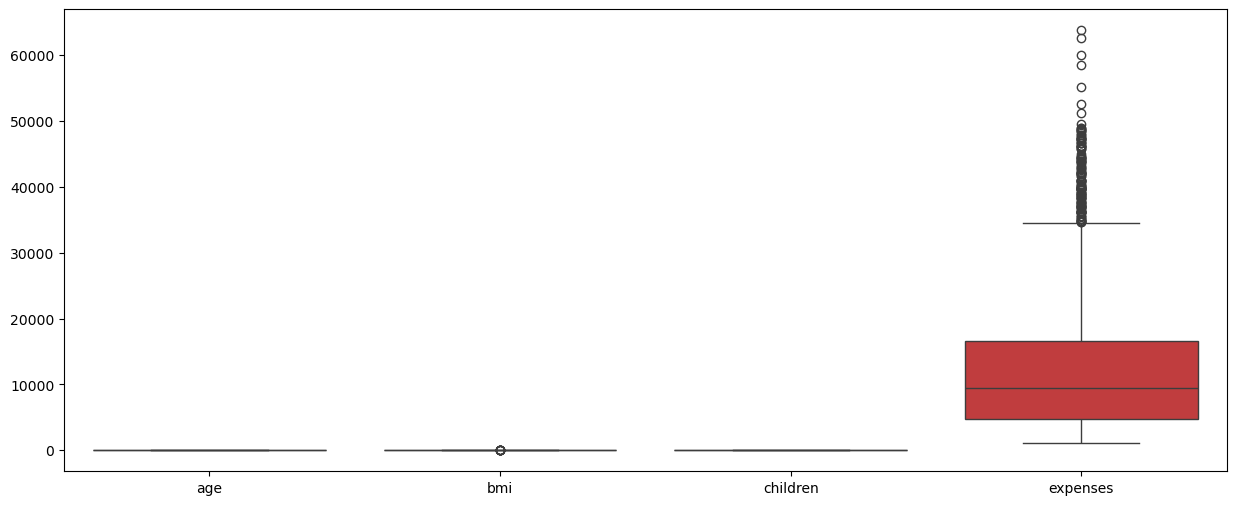

In [13]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=df_insurance)
plt.savefig("boxplot_insurance.png", bbox_inches='tight')
plt.show()

#### Nous pouvons comprendre avec ce boxplot que c'est la variable _expenses_ qui regroupe le plus de valeur abérrantes.

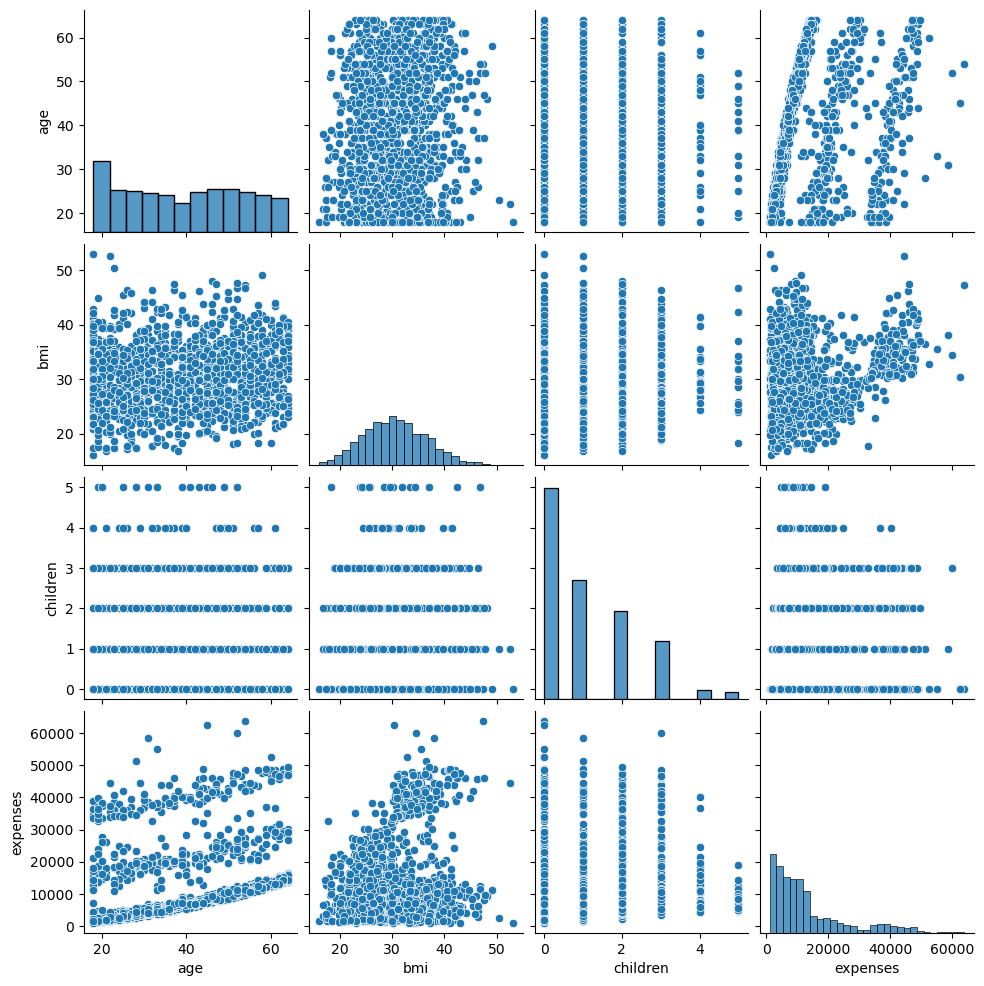

In [14]:
sns.pairplot(df_insurance)

<Axes: xlabel='bmi', ylabel='age'>

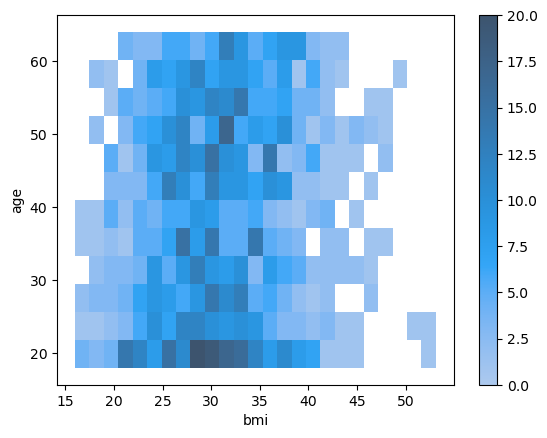

In [15]:
sns.histplot(data=df_insurance, x='bmi', y='age', cbar=True)

---

## Étape 3 : Prétraitement des Données

## Encodage des Variables Catégorielles

## One-Hot Encoding

In [16]:
df_insurance = pd.get_dummies(df_insurance, columns=['region'], dtype=int)

#### Choix du One_Hot Encoding pour la variable _region_ car les 4 différentes régions ne possèdent pas forcément un ordre logique entre elles (variable nominale).

## Label Encoding

In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_insurance['sex'] = le.fit_transform(df_insurance['sex'])
df_insurance['smoker'] = le.fit_transform(df_insurance['smoker'])

#### Encodage binaire ici pour les variables _sex_ et _smoker_ (0 et 1 pour remplacer le texte).

In [18]:
df_insurance

,age,sex,bmi,children,smoker,expenses,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.9,0,1,16884.92,0,0,0,1
1,18,1,33.8,1,0,1725.55,0,0,1,0
2,28,1,33.0,3,0,4449.46,0,0,1,0
3,33,1,22.7,0,0,21984.47,0,1,0,0
4,32,1,28.9,0,0,3866.86,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,1,31.0,3,0,10600.55,0,1,0,0
1334,18,0,31.9,0,0,2205.98,1,0,0,0
1335,18,0,36.9,0,0,1629.83,0,0,1,0
1336,21,0,25.8,0,0,2007.95,0,0,0,1


## Matrice de corrélation

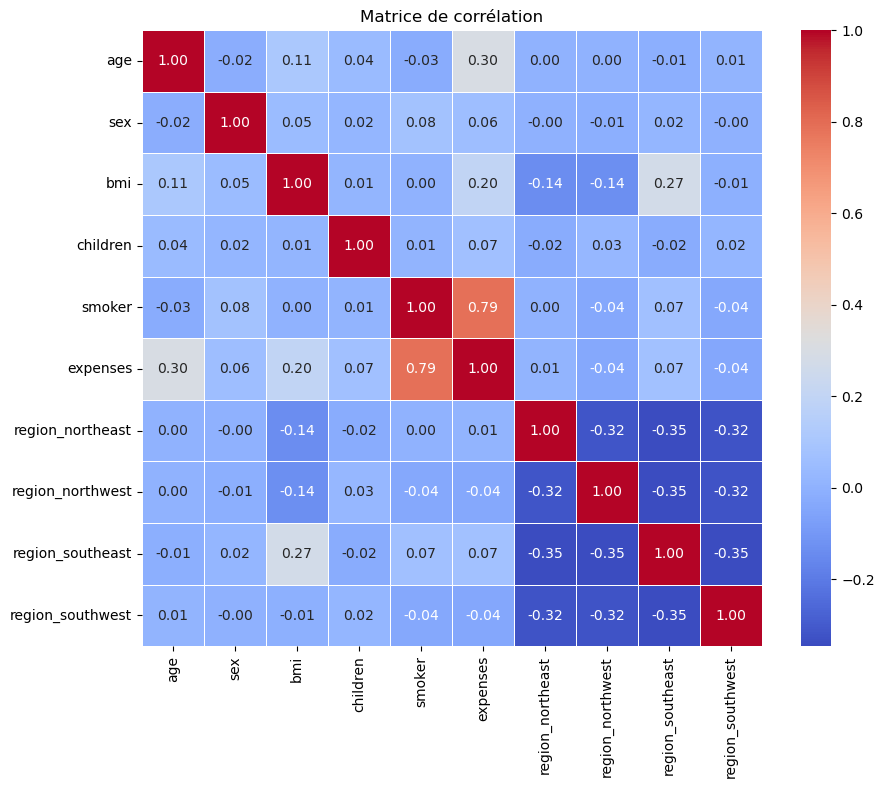

In [19]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_insurance.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matrice de corrélation")
plt.show()

#### Cette matrice de corrélation met principalement en évidence les facteurs qui influencent les dépenses (_expenses_). On observe une forte corrélation positive majeure entre le fait d'être fumeur (_smoker_ ) et le montant des dépenses. L'âge (_age_) présente également une influence modérée positive sur ces coûts, tout comme l'indice de masse corporelle (_bmi_) dans une moindre mesure. En revanche, les autres variables (sexe, nombre d'enfants et régions) affichent des liens quasi nuls avec les dépenses. Globalement, le tabagisme et l'âge se révèlent donc être les principaux moteurs de variation des coûts.

---

## Étape 4 : Sélection des Variables, Division des Données et Prétraitement

## Sélection des features et de la target

In [20]:
X = df_insurance.drop(columns=['expenses'])

In [21]:
y = df_insurance['expenses']

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

## Standartisation (des variables seulement numériques = _age_, _bmi_, _children_)

In [23]:
from sklearn.preprocessing import StandardScaler
features_to_scale = ['age', 'bmi', 'children']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
X_test_scaled[features_to_scale] = scaler.transform(X_test[features_to_scale])

---
## Étape 5 : Entraînement des Modèles de Régression

#### Modèle 1 : Régression Linéaire

In [24]:
from sklearn.linear_model import LinearRegression

model_1 = LinearRegression()

In [25]:
model_1.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


###

#### Modèle 2 : K-Nearest Neighbors (KNN) en Régression

In [26]:
from sklearn.neighbors import KNeighborsRegressor

model_2 = KNeighborsRegressor(n_neighbors=5)

In [27]:
model_2.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


###

#### Modèle 3 : Régression avec Arbre de Décision (Decision Tree Regressor)

In [28]:
from sklearn.tree import DecisionTreeRegressor

model_3 = DecisionTreeRegressor(random_state=42)

In [29]:
model_3.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


###

#### Modèle 4 : Forêt d'Arbres Décisionnels en Régression (Random Forest Regressor)

In [30]:
from sklearn.ensemble import RandomForestRegressor

model_4 = RandomForestRegressor(random_state=42)

In [31]:
model_4.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 

#### Modèle 5 : Support Vector Regression (SVR)

#### Scaler spécifique pour la variable cible $y$

In [32]:
from sklearn.svm import SVR

scaler_y = StandardScaler()

In [33]:
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))


model_5 = SVR(kernel='rbf', C=1000, gamma='scale') 
model_5.fit(X_train_scaled, y_train_scaled.ravel())

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1000
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


##### Le SVR est extrêmement sensible à l'échelle de la variable cible _expenses_, qui varie ici de quelques milliers à plus de 60 000. Pour qu'il fonctionne correctement, il faut également standardiser $y$, puis inverser la transformation (inverse_transform) une fois la prédiction faite.

---
## Étape 6 : Prédiction avec les Modèles

In [34]:
y_pred_model_regression = model_1.predict(X_test_scaled)
print(y_pred_model_regression)


y_pred_model_knn = model_2.predict(X_test_scaled)
print(y_pred_model_knn)


y_pred_model_arbre = model_3.predict(X_test)
print(y_pred_model_arbre)

y_pred_model_random_forest = model_4.predict(X_test)
print(y_pred_model_random_forest)

y_pred_model_svr = model_5.predict(X_test_scaled)
y_pred_svr = scaler_y.inverse_transform(y_pred_model_svr.reshape(-1, 1)) # Reconvertir à l'échelle d'origine
print(y_pred_svr)

[ 8.13594785e+03  5.73753051e+03  1.43754878e+04  3.17492191e+04
  8.96653643e+03  1.31467311e+04  3.04576861e+04  1.45222905e+03
  1.06200666e+04  1.13215144e+04  1.03774153e+04  3.31283463e+04
  3.10674732e+04  1.74144109e+04  1.08053885e+04  9.52866468e+03
  4.16225773e+03  3.17304468e+04  3.21853234e+03  5.23189302e+03
  3.54932046e+03  3.02741188e+04  1.49069893e+04  3.04556310e+04
  3.10981136e+04  5.50369233e+03  3.55131398e+04  3.65692987e+04
  1.14182801e+04  1.41993233e+04  6.51336631e+03  1.27339805e+04
  3.90817140e+02  1.20871022e+04  3.96571872e+04  1.23403323e+04
  4.74590903e+03  3.93305692e+03  3.08552851e+04  8.97254237e+03
  7.05454013e+03  3.00949581e+04  3.47895693e+04  1.22912933e+04
  7.37058509e+03  3.41972279e+03  6.22129056e+03  8.98344083e+03
  4.25174621e+03  9.00643158e+03  6.60146953e+03  1.20967740e+04
  3.12519965e+04  3.54324298e+03  1.10486122e+04  9.73702512e+03
  1.08241603e+04  2.42280315e+03  3.11772716e+04  9.40870909e+03
  1.55909670e+04  8.18810

#### Comparaison des modèles y_pred et y_test

In [35]:
resultats = pd.DataFrame({
    'expenses réelles': y_test.values,
    'Régression Linéaire': y_pred_model_regression,  
    'KNN': y_pred_model_knn,                
    'Arbre décision': y_pred_model_arbre,
    'Random Forest': y_pred_model_random_forest,
    'SVR': y_pred_svr.ravel(),                                # .ravel() résout le problème de dimension 
})

resultats.round(2).head(11)

,expenses réelles,Régression Linéaire,KNN,Arbre décision,Random Forest,SVR
0,8688.86,8135.95,9943.63,9361.33,10051.74,9387.32
1,5708.87,5737.53,7790.93,5253.52,6333.56,-1285.59
2,11436.74,14375.49,16508.52,10600.55,11381.08,12919.38
3,38746.36,31749.22,21295.18,44585.46,42214.93,42569.27
4,4463.21,8966.54,5320.40,4949.76,6317.59,5111.07
5,9304.70,13146.73,8206.77,8978.19,9727.82,10603.58
6,38511.63,30457.69,29120.11,36149.48,38661.93,68485.77
7,2150.47,1452.23,2266.26,2731.91,2192.51,3173.44
8,7345.73,10620.07,8280.88,7727.25,8756.51,8728.83
9,10264.44,11321.51,9665.53,10269.46,11034.72,13762.66


#### Les performances varient peu selon les modèles. Le modèle le plus performant semble être l'arbre de décision et le Random Forest.

---
## Étape 7 : Interprétation des Modèles de Régression

#### 1. **Régression Linéaire : Interprétation des Coefficients**

In [36]:
print("Intercept :", model_1.intercept_)

coefficients = pd.DataFrame(model_1.coef_, index=X_train_scaled.columns, columns=['Coefficient'])
print(coefficients)

Intercept : 8475.788115766976
                   Coefficient
age                3472.547601
sex                -101.760064
bmi                1929.025205
children            636.911983
smoker            23076.977936
region_northeast    472.675088
region_northwest     80.739571
region_southeast   -367.379000
region_southwest   -186.035659


#### Le coefficient le plus élevé est _smoker_ suivit de _age_ et _bmi_.

#####

#### 2. **K-Nearest Neighbors (KNN) en Régression : Importance des Données Locales**

In [37]:
index_client = 0
client_test = X_test_scaled[index_client : index_client + 1]  # Garde un format 2D

distances, indices_voisins = model_2.kneighbors(client_test)

print(
    "Dépenses réelles des voisins les plus proches :",
    y_train.iloc[indices_voisins[0]].values,)
print("Dépenses prédites par le KNN pour ce profil :", y_pred_model_knn[index_client])

Dépenses réelles des voisins les plus proches : [ 9361.33 10422.92  6837.37 11165.42 11931.13]
Dépenses prédites par le KNN pour ce profil : 9943.634


#### Les prédictions du modèle KNN reflète la moyenne arithmétique des dépenses réelles de ses 5 voisins les plus proches dans les données d'entraînement.

#####

#### 3. **Arbre de Décision : Visualisation des Décisions et Importance des Caractéristiques**

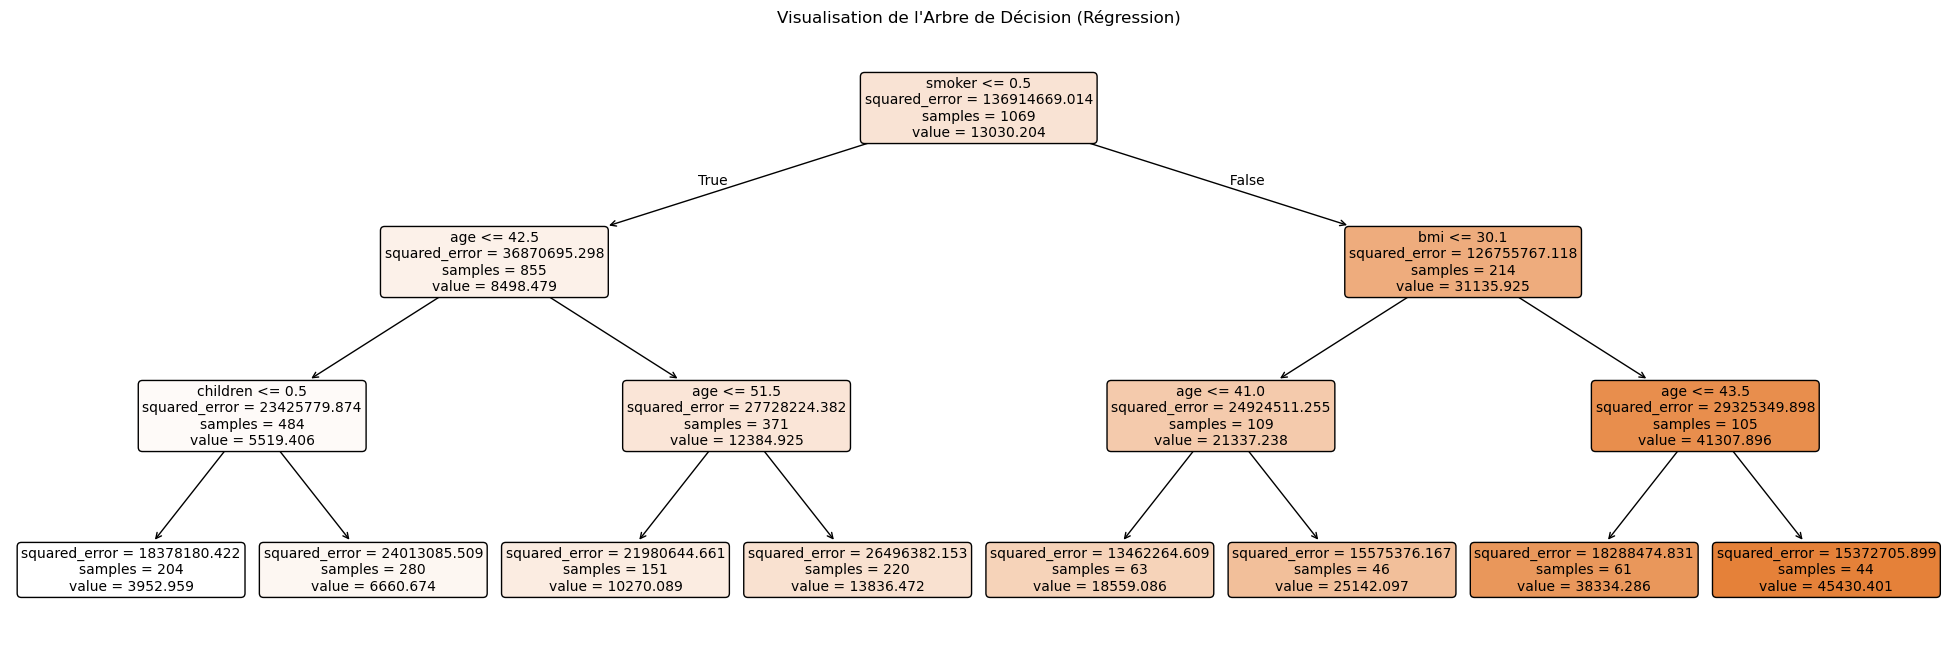

In [38]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

modele_arbre = DecisionTreeRegressor(max_depth=3, random_state=42)
modele_arbre.fit(X_train, y_train)

plt.figure(figsize=(25, 8), dpi=100)  
plot_tree(
    modele_arbre,
    feature_names=X.columns.tolist(),  
    filled=True,  
    rounded=True,  
    fontsize=10,  
)

plt.title("Visualisation de l'Arbre de Décision (Régression)")
plt.show()

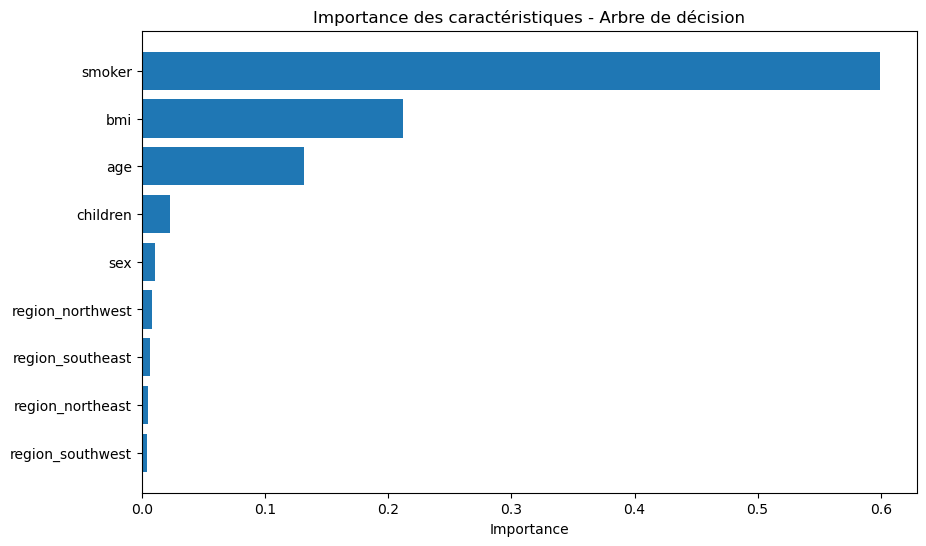

In [39]:
importances = model_3.feature_importances_
feature_names = X_train.columns
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.barh(feature_names[indices], importances[indices])
plt.xlabel("Importance")
plt.title("Importance des caractéristiques - Arbre de décision")
plt.show()

#### Les caractéristiques en haut de l'arbre sont effectivement les plus influentes, et il y a effectivement des relations intuitives entre les caractéritsiques et des décisions de l'arbre.

#####

#### 4. **Forêt d’Arbres Décisionnels (Random Forest) : Importance des Caractéristiques**

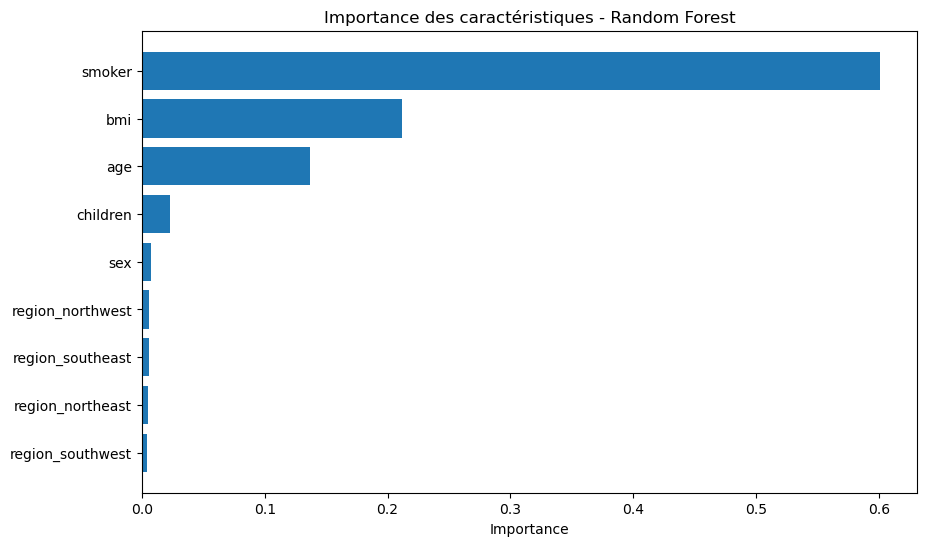

In [40]:
importances = model_4.feature_importances_
feature_names = X_train.columns
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.barh(feature_names[indices], importances[indices])
plt.xlabel("Importance")
plt.title("Importance des caractéristiques - Random Forest")
plt.show()

#### Les caractéristiques les plus importantes dans le modèle Random Forest sont exactement les mêmes que dans l'arbre de décision, et corresponds aux résultats des modèles précédents, notamment avec la prépondérance de la variable _smoker_.

#####

#### 5. **Support Vector Regression (SVR) : Points de Support et Coefficients**

In [41]:
support_indices = model_5.support_
print(f"Nombre de points de support : {len(support_indices)}")
print("Indices des premiers points de support :", support_indices[:10])

Nombre de points de support : 663
Indices des premiers points de support : [ 1  2  3  4  6  8  9 10 14 16]


#### SVR avec noyeau linéaire

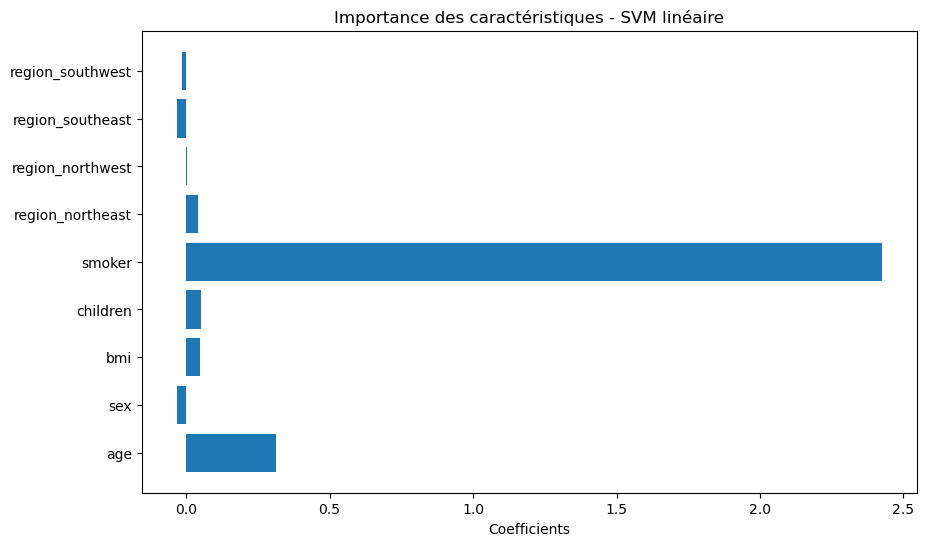

In [42]:
model_5_linear = SVR(kernel='linear')
model_5_linear.fit(X_train_scaled, y_train_scaled.ravel())                 # Utilisation de y_train_scaled

feature_names = X_train.columns
coefficients = model_5_linear.coef_.ravel()                                # .ravel() évite les erreurs de dimension

plt.figure(figsize=(10, 6))
plt.barh(feature_names, coefficients)
plt.xlabel("Coefficients")
plt.title("Importance des caractéristiques - SVM linéaire")
plt.show()

#### Le modèle a identifié 663 points de support parmi les données d'entraînement.
#### Le coefficient qui reflète le mieux l'influence des caractéritiques est _smoker_. _age_ et _bmi_ possèdent ici moins d'influence que prévu.

##

### Résumé et Comparaison des Modèles

#### Les différents modèles mettent en avant a peu près les mêmes caractéristiques comme les plus influentes, avec une prépondérance de _smoker_.
#### Le meilleure modèle semble être Random Forest, suivie de très près par l'arbre de décision.

---
## Étape 8 : Évaluation des Modèles de Régression

1. **Erreur Quadratique Moyenne (Mean Squarred Error - MSE)**  

#### MSE Régression Linéaire

In [43]:
from sklearn import metrics

In [44]:
model_1_mse = metrics.mean_squared_error(y_test, y_pred_model_regression)

#### MSE KNN

In [45]:
model_2_mse = metrics.mean_squared_error(y_test, y_pred_model_knn)

#### MSE Arbre de décision

In [46]:
model_3_mse = metrics.mean_squared_error(y_test, y_pred_model_arbre)

#### MSE Random Forest

In [47]:
model_4_mse = metrics.mean_squared_error(y_test, y_pred_model_random_forest)

#### MSE SVR

In [48]:
model_5_mse = metrics.mean_squared_error(y_test, y_pred_svr)

In [49]:
print("MSE Régression linéaire :", model_1_mse)
print("MSE KNN :", model_2_mse)
print("MSE Arbre de décision :", model_3_mse)
print("MSE Random Forest :", model_4_mse)
print("MSE SVR :", model_5_mse)

MSE Régression linéaire : 35481471.59594917
MSE KNN : 72122823.74669886
MSE Arbre de décision : 39987302.849754855
MSE Random Forest : 21483823.56999722
MSE SVR : 58158580.61235547


#### La MSE est particulièrement élevé pour le KNN notamment. Cela peux signifier que le modèle commet des erreurs de prédiction importantes. Comme la MSE élève les erreurs au carré, les grandes erreurs ont un impact particulièrement important sur cette métrique. Une MSE élevée peut donc être due à un modèle qui s’adapte moins bien aux données, à des relations non linéaires que le modèle ne parvient pas à capturer, ou à la présence de certaines observations difficiles à prédire.
#### Le modèle possédant la MSE la plus faible est Random Forest.

##

2. **Erreur Absolue Moyenne (Mean Absolute Error - MAE)**  

In [50]:
model_1_mae = metrics.mean_absolute_error(y_test, y_pred_model_regression)
model_2_mae = metrics.mean_absolute_error(y_test, y_pred_model_knn)
model_3_mae = metrics.mean_absolute_error(y_test, y_pred_model_arbre)
model_4_mae = metrics.mean_absolute_error(y_test, y_pred_model_random_forest)
model_5_mae = metrics.mean_absolute_error(y_test, y_pred_svr)

print("MAE Régression linéaire :", model_1_mae)
print("MAE KNN :", model_2_mae)
print("MAE Arbre de décision :", model_3_mae)
print("MAE Random Forest :", model_4_mae)
print("MAE SVR :", model_5_mae)

MAE Régression linéaire : 4177.2675960149245
MAE KNN : 4737.15804477612
MAE Arbre de décision : 2961.078917910447
MAE Random Forest : 2561.6992152985063
MAE SVR : 4606.13309370482


#### La MAE permet de comparer l'erreur moyenne absolue des différents modèles. Le modèle ayant la MAE la plus faible est celui dont les prédictions sont, en moyenne, les plus proches des valeurs réelles selon cette métrique. La comparaison doit être effectuée sur le même ensemble de test. Ici, c'est le modèle Random Forest qui se distingue le plus.
####  La MAE et la MSE peuvent conduire à des comparaisons différentes entre les modèles. La MAE considère les erreurs de manière proportionnelle et est donc moins sensible aux valeurs extrêmes. La MSE élève les erreurs au carré et pénalise fortement les grandes erreurs. Donc un modèle peut avoir une MAE relativement faible tout en ayant une MSE élevée s'il réalise quelques prédictions avec des erreurs particulièrement importantes. Cela peut notamment être lié à des valeurs abérrantes ou à des observations difficiles à prédire.
#### Ici, la MAE la plus faiblre et donc le modèle avec les meilleures prédictions est le Random Forest.

##

#### 3. **R² Score (Coefficient de Détermination)**  

In [51]:
model_1_r2 = metrics.r2_score(y_test, y_pred_model_regression)
model_2_r2 = metrics.r2_score(y_test, y_pred_model_knn)
model_3_r2 = metrics.r2_score(y_test, y_pred_model_arbre)
model_4_r2 = metrics.r2_score(y_test, y_pred_model_random_forest)
model_5_r2 = metrics.r2_score(y_test, y_pred_svr)

print("R² Régression linéaire :", model_1_r2)
print("R² KNN :", model_2_r2)
print("R² Arbre de décision :", model_3_r2)
print("R² Random Forest :", model_4_r2)
print("R² SVR :", model_5_r2)

R² Régression linéaire : 0.806909932904842
R² KNN : 0.6075077991429123
R² Arbre de décision : 0.7823892120896397
R² Random Forest : 0.883085093486796
R² SVR : 0.683501170400132


#### Le modèle avec le R² le plus élevé est le Random Forest. Cela signifie que oui le modèle explique bien la variances des données.
#### Les modèles avec un score bas sont notamment le KNN et le SVR. Cela indique que le modèle explique mal les variations de la variable cible à partir des variables explicatives.

##

## Interprétation des Résultats

In [52]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)                                         # Désactiver la notation scientifique

resultats = pd.DataFrame({
    "Modèle": ["Régression linéaire", "KNN", "Arbre de décision", "Random Forest", "SVR"],
    "MSE": [model_1_mse, model_2_mse, model_3_mse, model_4_mse, model_5_mse],
    "MAE": [model_1_mae, model_2_mae, model_3_mae, model_4_mae, model_5_mae],
    "R²": [model_1_r2, model_2_r2, model_3_r2, model_4_r2, model_5_r2]})


print(resultats.round(5))

                Modèle         MSE     MAE   R²
0  Régression linéaire 35481471.60 4177.27 0.81
1                  KNN 72122823.75 4737.16 0.61
2    Arbre de décision 39987302.85 2961.08 0.78
3        Random Forest 21483823.57 2561.70 0.88
4                  SVR 58158580.61 4606.13 0.68


##

### Conclusion des Résultats et Choix du Modèle Optimal

#### Analyse des performances du meilleur et du pire modèle

##### Le meilleur modèle est le Random Forest. C'est le modèle le plus performant. Il affiche le coefficient de détermination le plus élevé, ce qui signifie qu'il parvient à expliquer 88 % de la variance des dépenses d'assurance. Il présente également la MAE la plus faible, ce qui signifie qu'en moyenne, ses prédictions se trompent de seulement ~2 561 $. Contrairement à un arbre de décision unique, le Random Forest combine plusieurs arbres de décision, ce qui permet de lisser les erreurs, d'éviter le surapprentissage et de capturer des relations non-linéaires complexes (comme l'impact croisé du tabagisme et de l'âge).
##### Le modèle le moins performant est le KNN, affichant le R² le plus bas ainsi que le MSE le plus élevé, ce qui traduit des erreurs de prédiction globales plus importantes sur ce jeu de données. 

#### Comparaison des autres modèles

##### La Régression Linéaire reste un bon modèle de référence. Elle a réussi à capturer la tendance globale des données (notamment grâce à l'impact fort du profil fumeur).
##### L'Arbre de décision obtient d'excellents résultats, affichant même une MAE plus faible que la régression linéaire, tout en offrant une excellente interprétabilité visuelle.
##### Enfin, le SVR et le KNN se montrent moins performants ; le KNN souffre notamment de la dimensionnalité et de la difficulté à pondérer idéalement les variables, tandis que le SVR affiche un R² plus faible et nécessite un réglage fin de ses hyperparamètres pour éviter de diverger. 

#### Conclusion des Résultats et Choix du Modèle Optimal

##### Le modèle le plus adapté en fonction des données est le Random Forest. Il obtient les meilleures performances globales selon les métriques utilisées : une MSE et une MAE faibles ainsi qu'un R² élevé. Cela signifie qu'il commet globalement moins d'erreurs de prédiction et qu'il explique une plus grande partie de la variabilité de la variable cible. De plus, sa capacité à combiner de multiples arbres de décision permet d'absorber la complexité des données (notamment l'impact critique du tabagisme combiné à l'âge et au BMI).

---
## Étape 9 : Sauvegarde du modèle pour le simulateur Streamlit

In [53]:
import joblib

joblib.dump(model_4, "../streamlit/model/modele_random_forest.joblib", compress=3)
joblib.dump(list(X_train.columns), "../streamlit/model/colonnes_modele.joblib")

['../streamlit/model/colonnes_modele.joblib']

In [54]:
modele_test = joblib.load("../streamlit/model/modele_random_forest.joblib")
colonnes_test = joblib.load("../streamlit/model/colonnes_modele.joblib")

print(colonnes_test)
print(modele_test.predict(X_test[colonnes_test].head(3)))
print(y_pred_model_random_forest[:3])

['age', 'sex', 'bmi', 'children', 'smoker', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']
[10051.7437  6333.5554 11381.0802]
[10051.7437  6333.5554 11381.0802]
